In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score, recall_score, \
							precision_score, precision_recall_curve, roc_curve, auc
from sklearn.calibration import calibration_curve

import os
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
from dateutil.relativedelta import relativedelta
import ptitprince as pt



import scorecardpy as sc
from scorecardpy import woebin, woebin_ply, scorecard

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s06")

np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv("train.csv")
dt = pd.read_csv("test.csv")
df.head()


,customer_id,age,income,employment_years,credit_history_length,num_open_accounts,num_credit_inquiries,loan_amount,credit_utilization,savings_balance,debt_to_income,savings_to_loan,default
0,2215,33,2348.508502,11.609655,12.518307,4,2,3128.634506,0.400894,441.505358,1.332179,0.141118,0
1,2582,57,4823.815137,29.366507,29.231106,4,0,17589.950904,0.230374,6564.147572,3.646481,0.373176,0
2,1662,35,2940.413100,20.136902,25.354618,3,2,3988.284147,0.373365,2604.801611,1.356369,0.653113,0
3,3027,29,4381.170349,13.005250,18.376884,4,3,9502.451646,0.280574,2771.703813,2.168930,0.291683,1
4,4343,52,1791.573390,31.344486,30.000000,5,5,5054.886087,0.068373,1894.061920,2.821479,0.374699,0


In [3]:
dt.head()

,customer_id,age,income,employment_years,credit_history_length,num_open_accounts,num_credit_inquiries,loan_amount,credit_utilization,savings_balance,debt_to_income,savings_to_loan
0,2,35,3026.188849,12.030931,11.175373,3,0,6182.495941,0.244447,3788.765813,2.042997,0.612821
1,3,63,3461.164718,40.000000,30.000000,1,2,8100.800998,0.277225,2338.384375,2.340484,0.288661
2,4,28,623.303486,12.146441,16.072591,2,1,2475.098839,0.513279,291.031814,3.970937,0.117584
3,5,41,3193.434493,21.277601,23.108662,1,3,6562.820020,0.308483,4025.095442,2.055098,0.613318
4,9,31,5535.931566,8.022126,9.706850,3,2,21891.997390,0.182953,2415.041572,3.954528,0.110316


In [4]:
# ponemos como etiqueta la columna customer_id
df.set_index('customer_id', inplace=True)
print(df.head())


             age       income  employment_years  credit_history_length  \
customer_id                                                              
2215          33  2348.508502         11.609655              12.518307   
2582          57  4823.815137         29.366507              29.231106   
1662          35  2940.413100         20.136902              25.354618   
3027          29  4381.170349         13.005250              18.376884   
4343          52  1791.573390         31.344486              30.000000   

             num_open_accounts  num_credit_inquiries   loan_amount  \
customer_id                                                          
2215                         4                     2   3128.634506   
2582                         4                     0  17589.950904   
1662                         3                     2   3988.284147   
3027                         4                     3   9502.451646   
4343                         5                     5   5054.8

In [5]:
dt.set_index('customer_id', inplace=True)
print(dt.head())

             age       income  employment_years  credit_history_length  \
customer_id                                                              
2             35  3026.188849         12.030931              11.175373   
3             63  3461.164718         40.000000              30.000000   
4             28   623.303486         12.146441              16.072591   
5             41  3193.434493         21.277601              23.108662   
9             31  5535.931566          8.022126               9.706850   

             num_open_accounts  num_credit_inquiries   loan_amount  \
customer_id                                                          
2                            3                     0   6182.495941   
3                            1                     2   8100.800998   
4                            2                     1   2475.098839   
5                            1                     3   6562.820020   
9                            3                     2  21891.9

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 6000 entries, 2215 to 1247
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    6000 non-null   int64  
 1   income                 5721 non-null   float64
 2   employment_years       5674 non-null   float64
 3   credit_history_length  5716 non-null   float64
 4   num_open_accounts      6000 non-null   int64  
 5   num_credit_inquiries   6000 non-null   int64  
 6   loan_amount            6000 non-null   float64
 7   credit_utilization     5690 non-null   float64
 8   savings_balance        5676 non-null   float64
 9   debt_to_income         6000 non-null   float64
 10  savings_to_loan        6000 non-null   float64
 11  default                6000 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 609.4 KB


In [7]:
#muestra los valores nulos en las variables train
df.isnull().mean().to_frame().sort_values(by=0, ascending=False).T *100



,employment_years,savings_balance,credit_utilization,credit_history_length,income,age,num_credit_inquiries,num_open_accounts,loan_amount,debt_to_income,savings_to_loan,default
0,5.433333,5.4,5.166667,4.733333,4.65,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
#muestra valores nulos en el test   
dt.isnull().mean().to_frame().sort_values(by=0, ascending=False).T *100

,savings_balance,credit_history_length,income,credit_utilization,employment_years,age,num_open_accounts,loan_amount,num_credit_inquiries,debt_to_income,savings_to_loan
0,5.55,5.25,5.25,4.6,4.5,0.0,0.0,0.0,0.0,0.0,0.0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'employment_years'}>],
       [<Axes: title={'center': 'credit_history_length'}>,
        <Axes: title={'center': 'num_open_accounts'}>,
        <Axes: title={'center': 'num_credit_inquiries'}>],
       [<Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'credit_utilization'}>,
        <Axes: title={'center': 'savings_balance'}>],
       [<Axes: title={'center': 'debt_to_income'}>,
        <Axes: title={'center': 'savings_to_loan'}>,
        <Axes: title={'center': 'default'}>]], dtype=object)

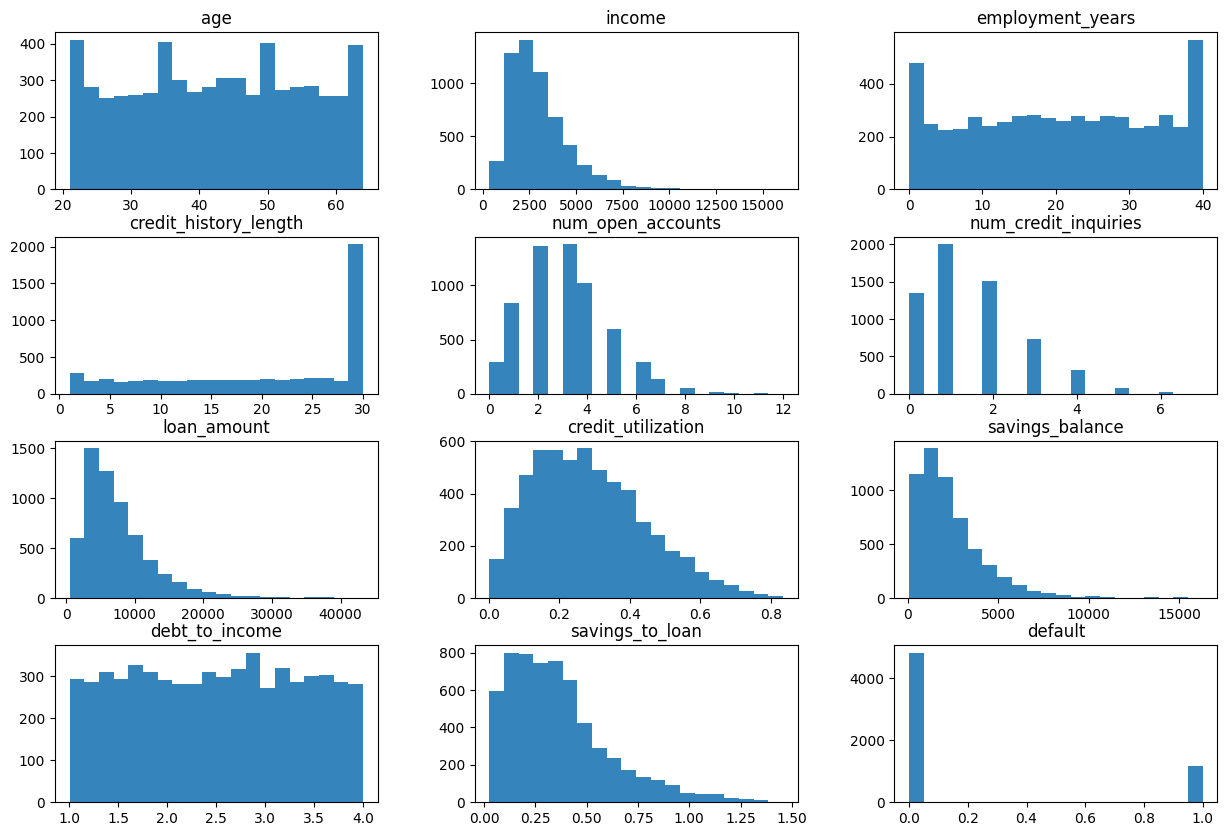

In [9]:
df.hist(bins=20, figsize=(15,10), alpha=0.9, grid=False)

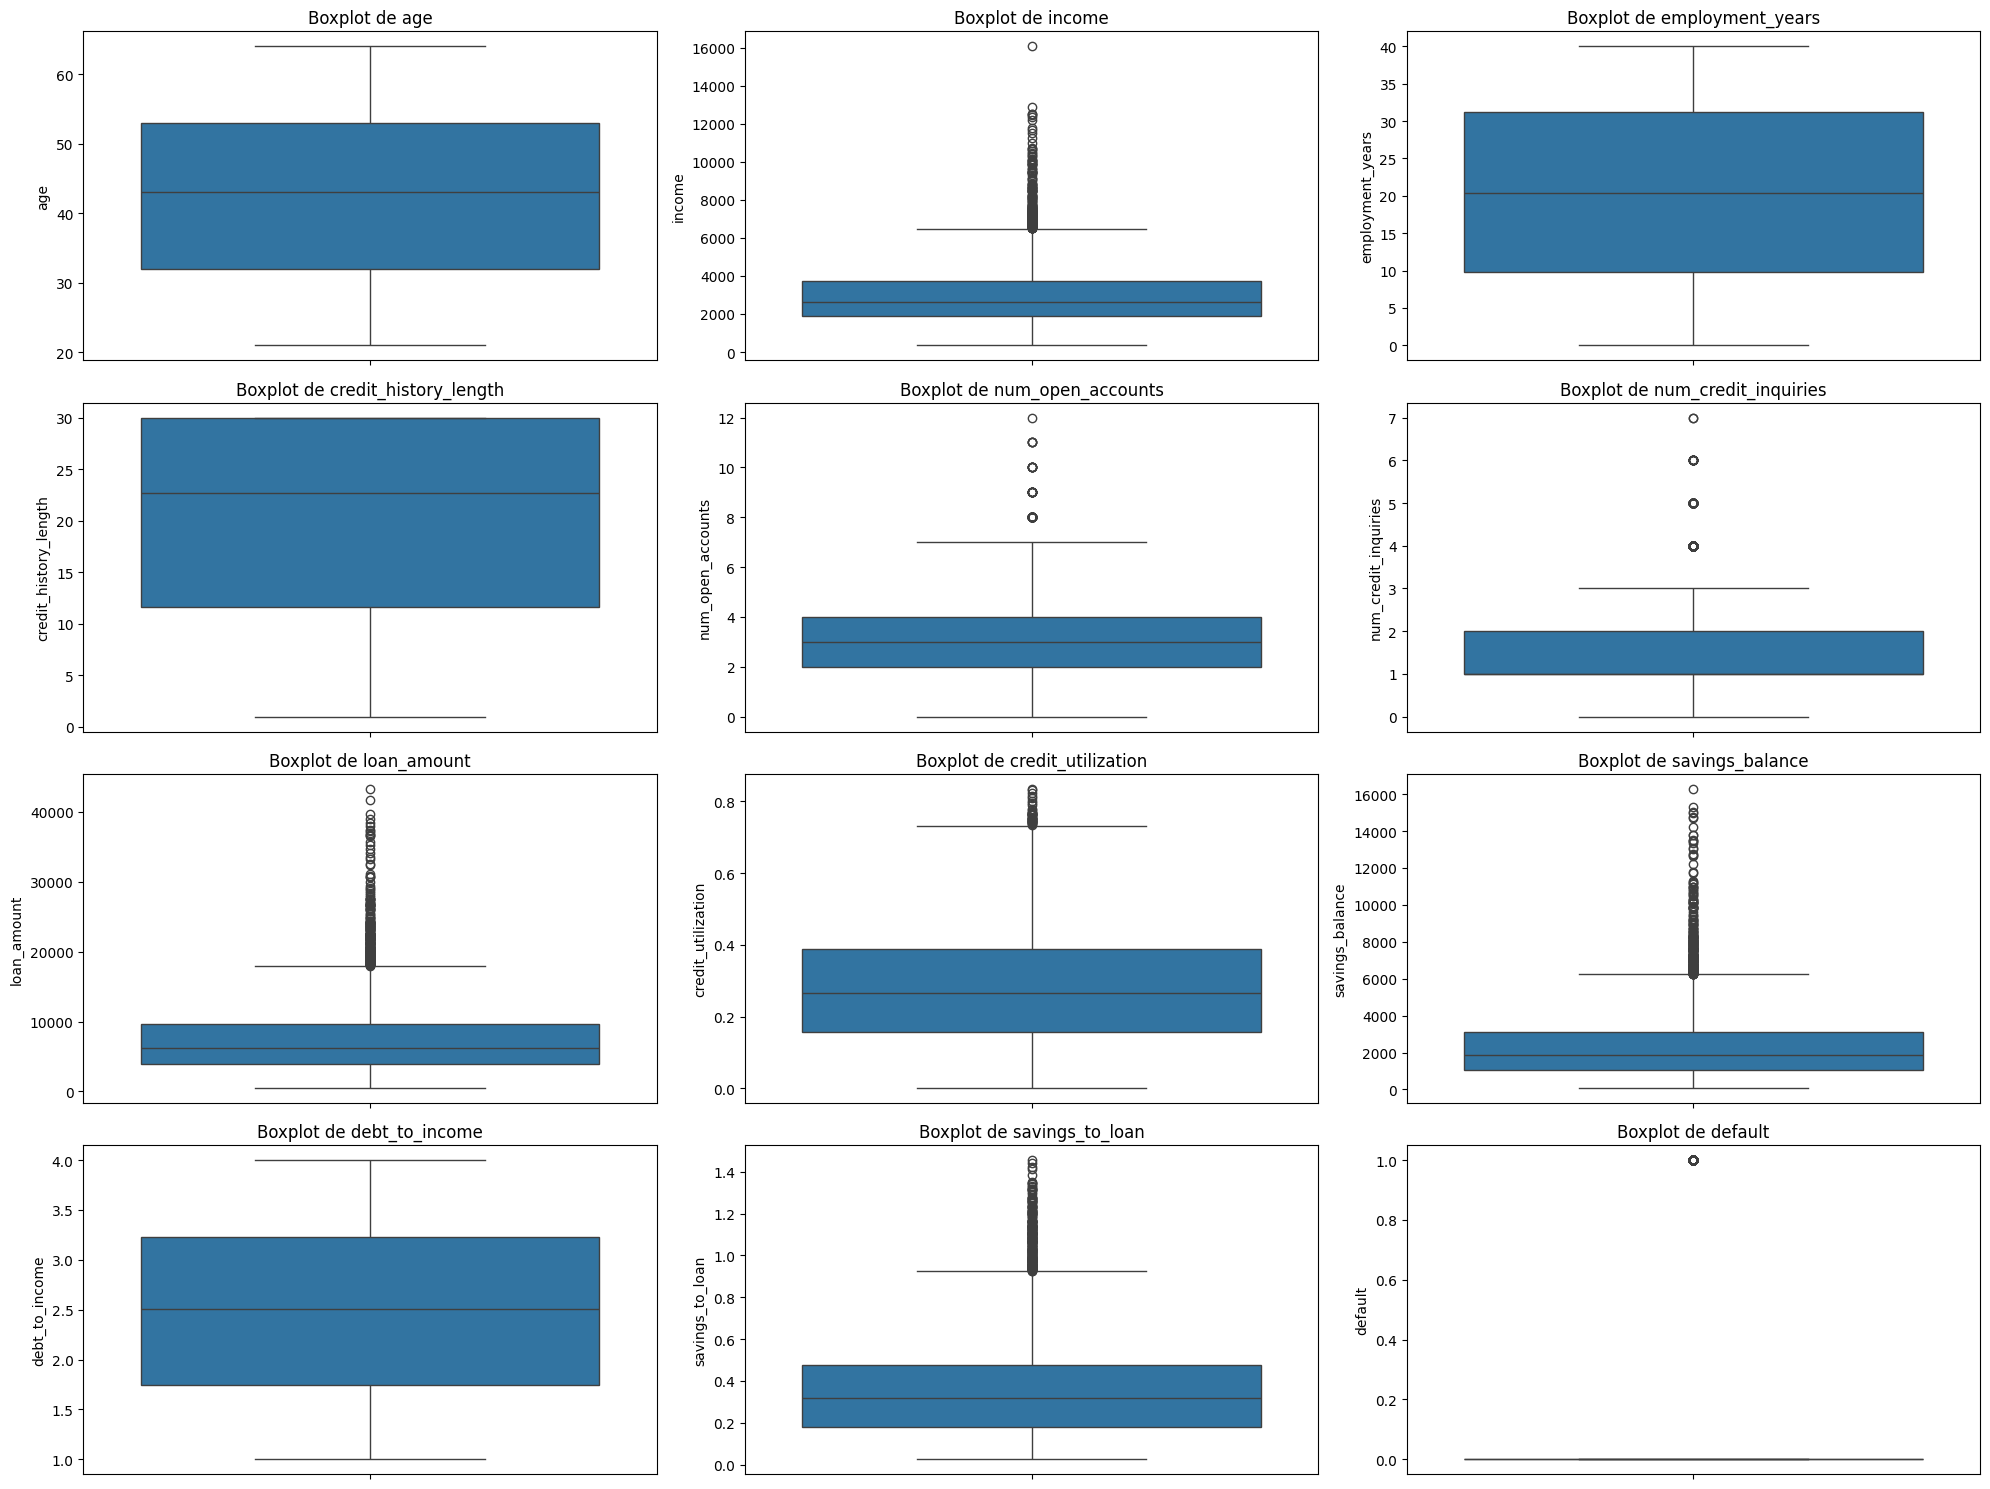

In [10]:
# muestra los boxplots de las variables numéricas para detectar posibles outliers

v_num = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15))
for col, ax in zip(v_num, axes.flatten()[:len(v_num)]):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f'Boxplot de {col}')
    ax.grid(False)
plt.tight_layout()
plt.show()

## Analisis bivariado

In [11]:
df.head()

,age,income,employment_years,credit_history_length,num_open_accounts,num_credit_inquiries,loan_amount,credit_utilization,savings_balance,debt_to_income,savings_to_loan,default
customer_id,,,,,,,,,,,,
2215,33,2348.508502,11.609655,12.518307,4,2,3128.634506,0.400894,441.505358,1.332179,0.141118,0
2582,57,4823.815137,29.366507,29.231106,4,0,17589.950904,0.230374,6564.147572,3.646481,0.373176,0
1662,35,2940.413100,20.136902,25.354618,3,2,3988.284147,0.373365,2604.801611,1.356369,0.653113,0
3027,29,4381.170349,13.005250,18.376884,4,3,9502.451646,0.280574,2771.703813,2.168930,0.291683,1
4343,52,1791.573390,31.344486,30.000000,5,5,5054.886087,0.068373,1894.061920,2.821479,0.374699,0


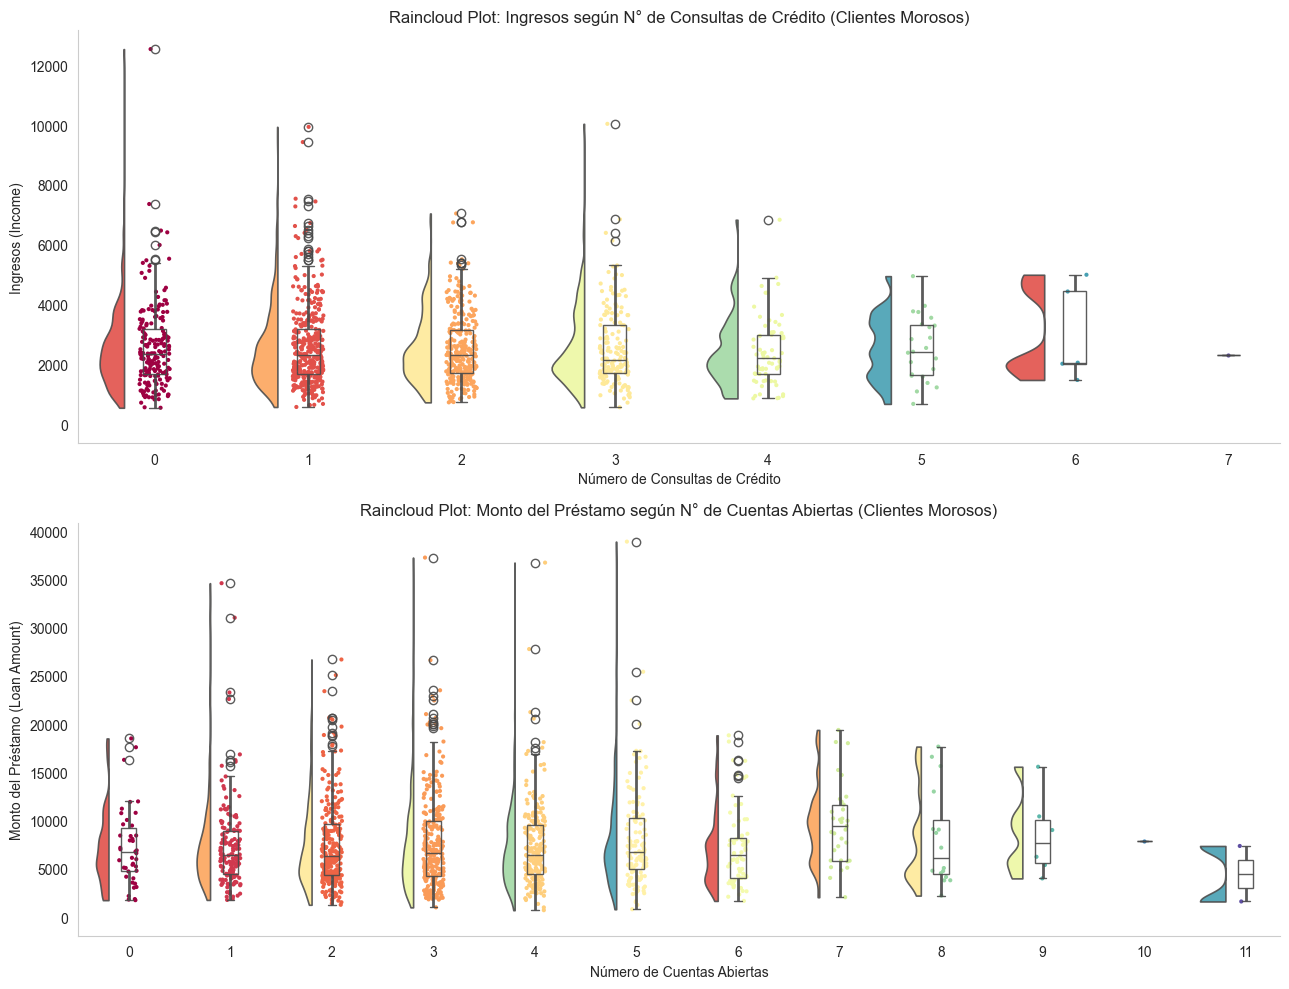

In [12]:
sns.set_style("whitegrid")  
fig, axes = plt.subplots(2, 1, figsize=(13, 10)) 

# --- PRIMER GRÁFICO
pt.RainCloud(x="num_credit_inquiries", y="income", data=df[df['default']==1], 
             palette='Spectral', bw=0.2, width_viol=0.5, ax=axes[0],
             alpha=0.9, jitter=True, linewidth=1.2) 
axes[0].set_title("Raincloud Plot: Ingresos según N° de Consultas de Crédito (Clientes Morosos)", fontsize=12)
axes[0].set_xlabel("Número de Consultas de Crédito", fontsize=10)
axes[0].set_ylabel("Ingresos (Income)", fontsize=10)
axes[0].grid(False)
sns.despine(ax=axes[0])

# --- SEGUNDO GRÁFICO
pt.RainCloud(x="num_open_accounts", y="loan_amount", data=df[df['default']==1],
             palette='Spectral', bw=0.2, width_viol=0.5, ax=axes[1],
             alpha=0.9, jitter=True, linewidth=1.2)
axes[1].set_title("Raincloud Plot: Monto del Préstamo según N° de Cuentas Abiertas (Clientes Morosos)", fontsize=12)
axes[1].set_xlabel("Número de Cuentas Abiertas", fontsize=10)
axes[1].set_ylabel("Monto del Préstamo (Loan Amount)", fontsize=10)
axes[1].grid(False)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

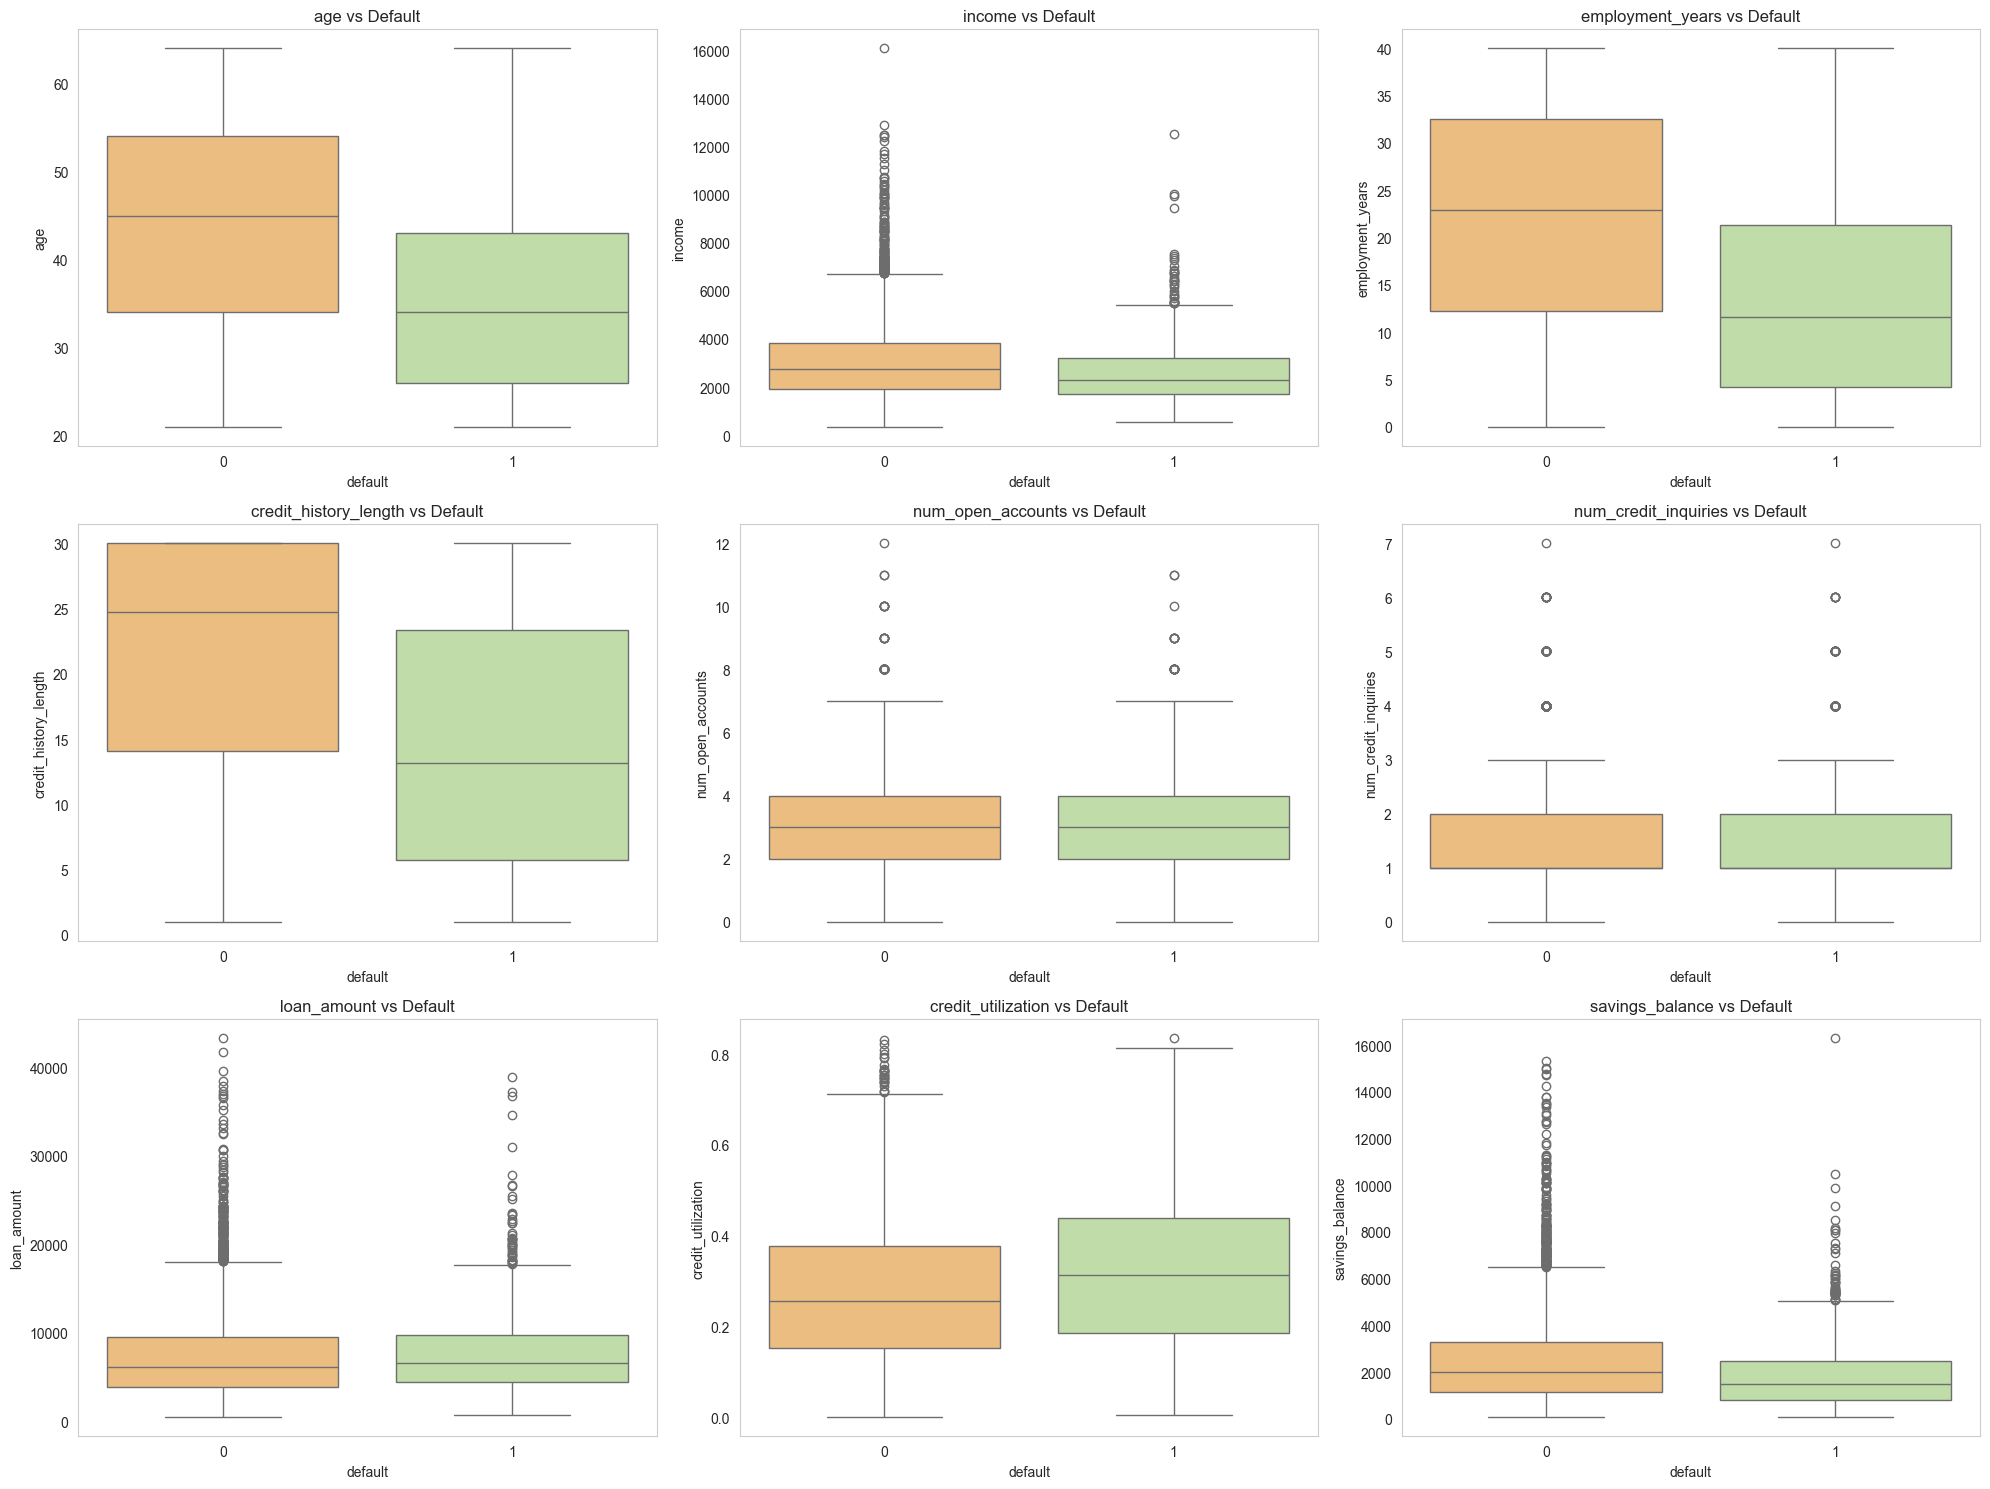

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
for col, ax in zip(v_num, axes.flatten()[:len(v_num)]):
    sns.boxplot(data=df, x='default', y=col, ax=ax, palette="Spectral")
    ax.set_title(f'{col} vs Default')
    ax.grid(False)
plt.tight_layout()
plt.show()

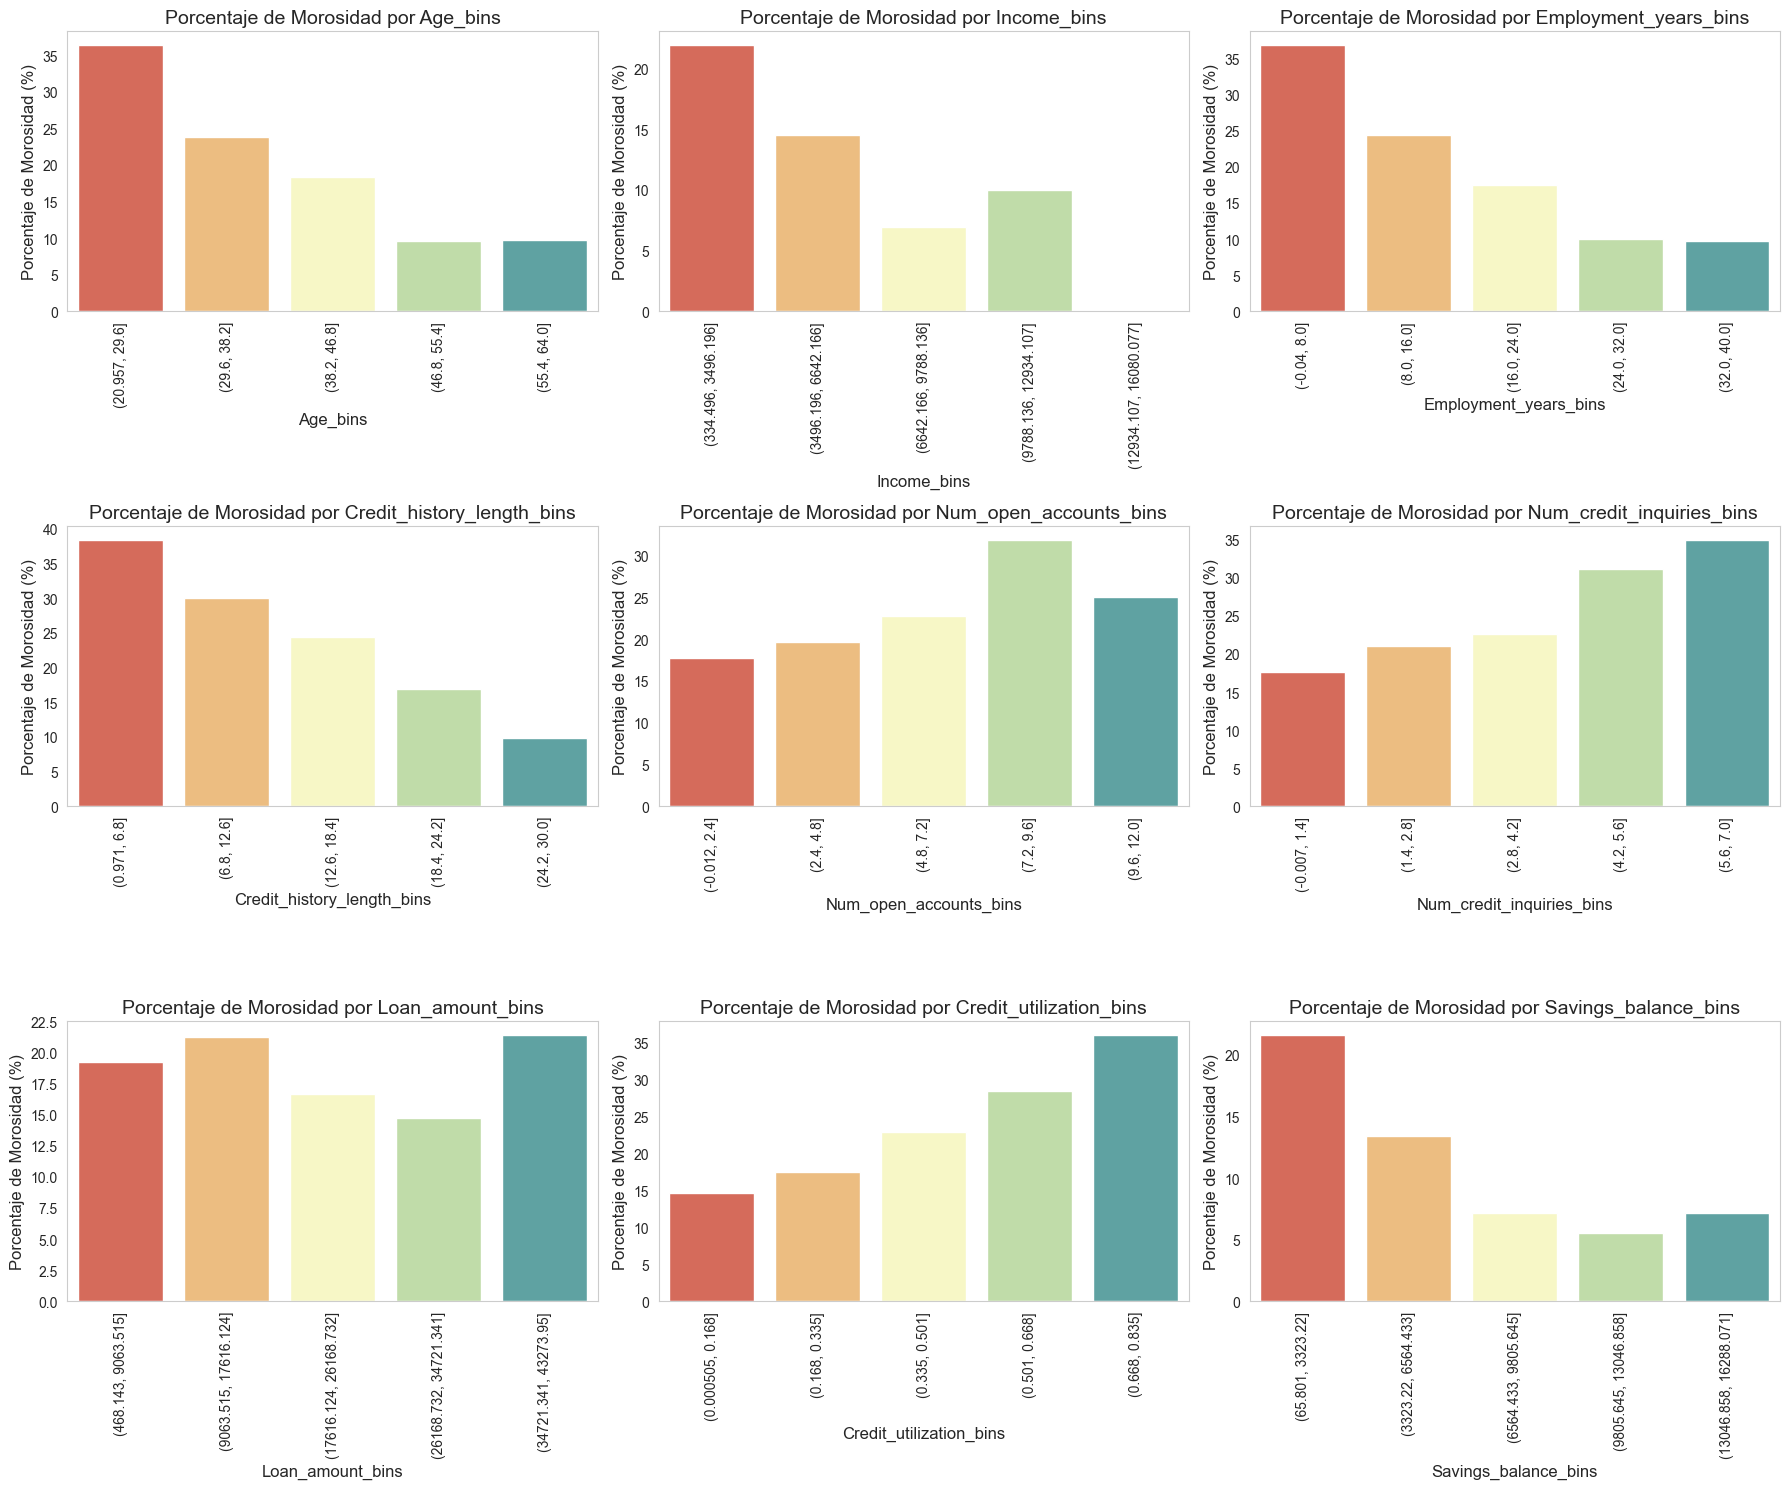

In [14]:

var = [x for x in v_num]
var_list = []

for i in var:
	df[f'{i}_bins'] = pd.cut(df[i], 5)
	var_list.append(f'{i}_bins')

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
for col, ax in zip(var_list, axes.flatten()): 
    mora_percent = df.groupby(col)['default'].mean().reset_index()
    mora_percent['default'] *= 100 
    sns.barplot(data=mora_percent, x=col, y='default', ax=ax, palette="Spectral")
    ax.set_title(f'Porcentaje de Morosidad por {col.capitalize()}', fontsize=14)
    ax.set_xlabel(col.capitalize(), fontsize=12)
    ax.set_ylabel("Porcentaje de Morosidad (%)", fontsize=12)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(False)

for ax in  axes.flatten()[len(var_list):]:
    ax.set_visible(False)  # o ax.axis('off')
    
plt.tight_layout()
plt.show()

## **2.3 Análisis Multivariado**

Los puntos mas importantes en este punto son:
- Multicolinealidad
- Variables duplicadas conceptualmente
- Correlación con target

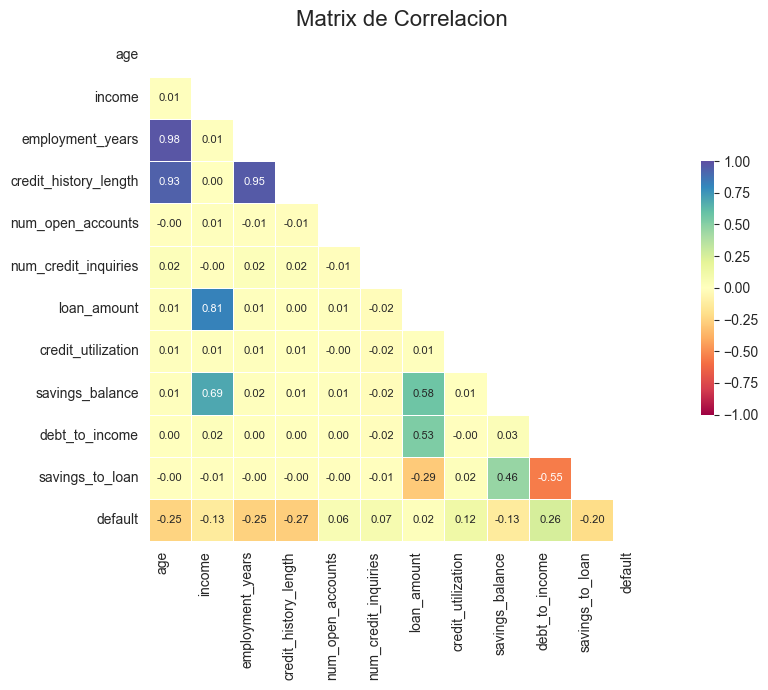

In [15]:
corr = df[v_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 7))
sns.set_style("white")  

sns.heatmap(corr, mask=mask, cmap="Spectral", 
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5,
            cbar_kws={"shrink": 0.5, "aspect": 20}, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matrix de Correlacion", fontsize=16)
plt.tight_layout()
plt.show()

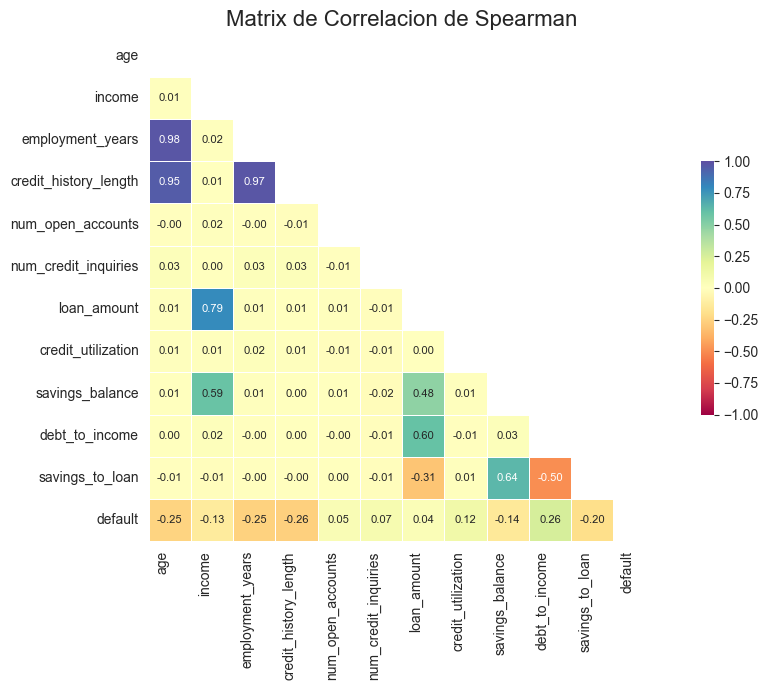

In [16]:
corr = df[v_num].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 7))
sns.set_style("white")  

sns.heatmap(corr, mask=mask, cmap="Spectral", 
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5,
            cbar_kws={"shrink": 0.5, "aspect": 20}, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matrix de Correlacion de Spearman", fontsize=16)
plt.tight_layout()
plt.show()

# 1.2 Tratamiento de variables

In [17]:
# eliminamos variables correlacionadas al |80%|

df_clean = df.drop(columns=['age', 'employment_years', 'loan_amount'])
dt_clean = dt.drop(columns=['age', 'employment_years', 'loan_amount'])

df_clean.info()



<class 'pandas.DataFrame'>
Index: 6000 entries, 2215 to 1247
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   income                      5721 non-null   float64 
 1   credit_history_length       5716 non-null   float64 
 2   num_open_accounts           6000 non-null   int64   
 3   num_credit_inquiries        6000 non-null   int64   
 4   credit_utilization          5690 non-null   float64 
 5   savings_balance             5676 non-null   float64 
 6   debt_to_income              6000 non-null   float64 
 7   savings_to_loan             6000 non-null   float64 
 8   default                     6000 non-null   int64   
 9   age_bins                    6000 non-null   category
 10  income_bins                 5721 non-null   category
 11  employment_years_bins       5674 non-null   category
 12  credit_history_length_bins  5716 non-null   category
 13  num_open_accounts_bins      600

In [18]:
#como son porcentajes pequeños entonces vamos imputarlos con la mediana

cols_nulas = ['savings_balance', 'income', 'credit_history_length', 'credit_utilization']
imputer = SimpleImputer(strategy='median')
df_clean[cols_nulas] = imputer.fit_transform(df_clean[cols_nulas])
dt_clean[cols_nulas] = imputer.fit_transform(dt_clean[cols_nulas])
df_clean.isnull().sum()

income                          0
credit_history_length           0
num_open_accounts               0
num_credit_inquiries            0
credit_utilization              0
savings_balance                 0
debt_to_income                  0
savings_to_loan                 0
default                         0
age_bins                        0
income_bins                   279
employment_years_bins         326
credit_history_length_bins    284
num_open_accounts_bins          0
num_credit_inquiries_bins       0
loan_amount_bins                0
credit_utilization_bins       310
savings_balance_bins          324
debt_to_income_bins             0
savings_to_loan_bins            0
default_bins                    0
dtype: int64

In [19]:
 # Buscamos todas las columnas que contengan '_bins' en su nombre y luego dropeamos
columnas_bins = [col for col in df_clean.columns if 'bins' in col]
df_clean.drop(columns=columnas_bins, inplace=True)
print(df_clean.isnull().sum())

income                   0
credit_history_length    0
num_open_accounts        0
num_credit_inquiries     0
credit_utilization       0
savings_balance          0
debt_to_income           0
savings_to_loan          0
default                  0
dtype: int64


In [20]:
# normalización variables

from sklearn.preprocessing import MinMaxScaler
#Definimos las variables menos "Y"
columnas_a_normalizar = [
    'income', 'num_open_accounts', 
    'num_credit_inquiries', 'credit_utilization', 
    'savings_balance', 'debt_to_income', 'savings_to_loan','credit_history_length'
]
scaler = MinMaxScaler()
df_clean[columnas_a_normalizar] = scaler.fit_transform(df_clean[columnas_a_normalizar])
dt_clean[columnas_a_normalizar] = scaler.fit_transform(dt_clean[columnas_a_normalizar])

print(df_clean[columnas_a_normalizar].describe().loc[['min', 'max']])

     income  num_open_accounts  num_credit_inquiries  credit_utilization  \
min     0.0                0.0                   0.0                 0.0   
max     1.0                1.0                   1.0                 1.0   

     savings_balance  debt_to_income  savings_to_loan  credit_history_length  
min              0.0             0.0              0.0                    0.0  
max              1.0             1.0              1.0                    1.0  


In [21]:
df_clean.head()

,income,credit_history_length,num_open_accounts,num_credit_inquiries,credit_utilization,savings_balance,debt_to_income,savings_to_loan,default
customer_id,,,,,,,,,
2215,0.127038,0.397183,0.333333,0.285714,0.479444,0.022183,0.110442,0.080626,0
2582,0.284401,0.973486,0.333333,0.000000,0.274829,0.399982,0.882199,0.242853,0
1662,0.164667,0.839814,0.250000,0.285714,0.446410,0.155670,0.118508,0.438551,0
3027,0.256261,0.599203,0.333333,0.428571,0.335067,0.165969,0.389475,0.185883,1
4343,0.091631,1.000000,0.416667,0.714286,0.080437,0.111813,0.607083,0.243918,0


In [22]:
df_clean.describe()

,income,credit_history_length,num_open_accounts,num_credit_inquiries,credit_utilization,savings_balance,debt_to_income,savings_to_loan,default
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,0.167171,0.663198,0.252458,0.213952,0.339429,0.139662,0.498803,0.237759,0.195833
std,0.099329,0.330767,0.145005,0.173827,0.186257,0.114129,0.286589,0.173940,0.396874
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.098736,0.390094,0.166667,0.142857,0.196404,0.061747,0.247617,0.107519,0.000000
50%,0.145929,0.746795,0.250000,0.142857,0.316799,0.111493,0.502487,0.205669,0.000000
75%,0.210288,1.000000,0.333333,0.285714,0.455464,0.181573,0.742653,0.316511,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


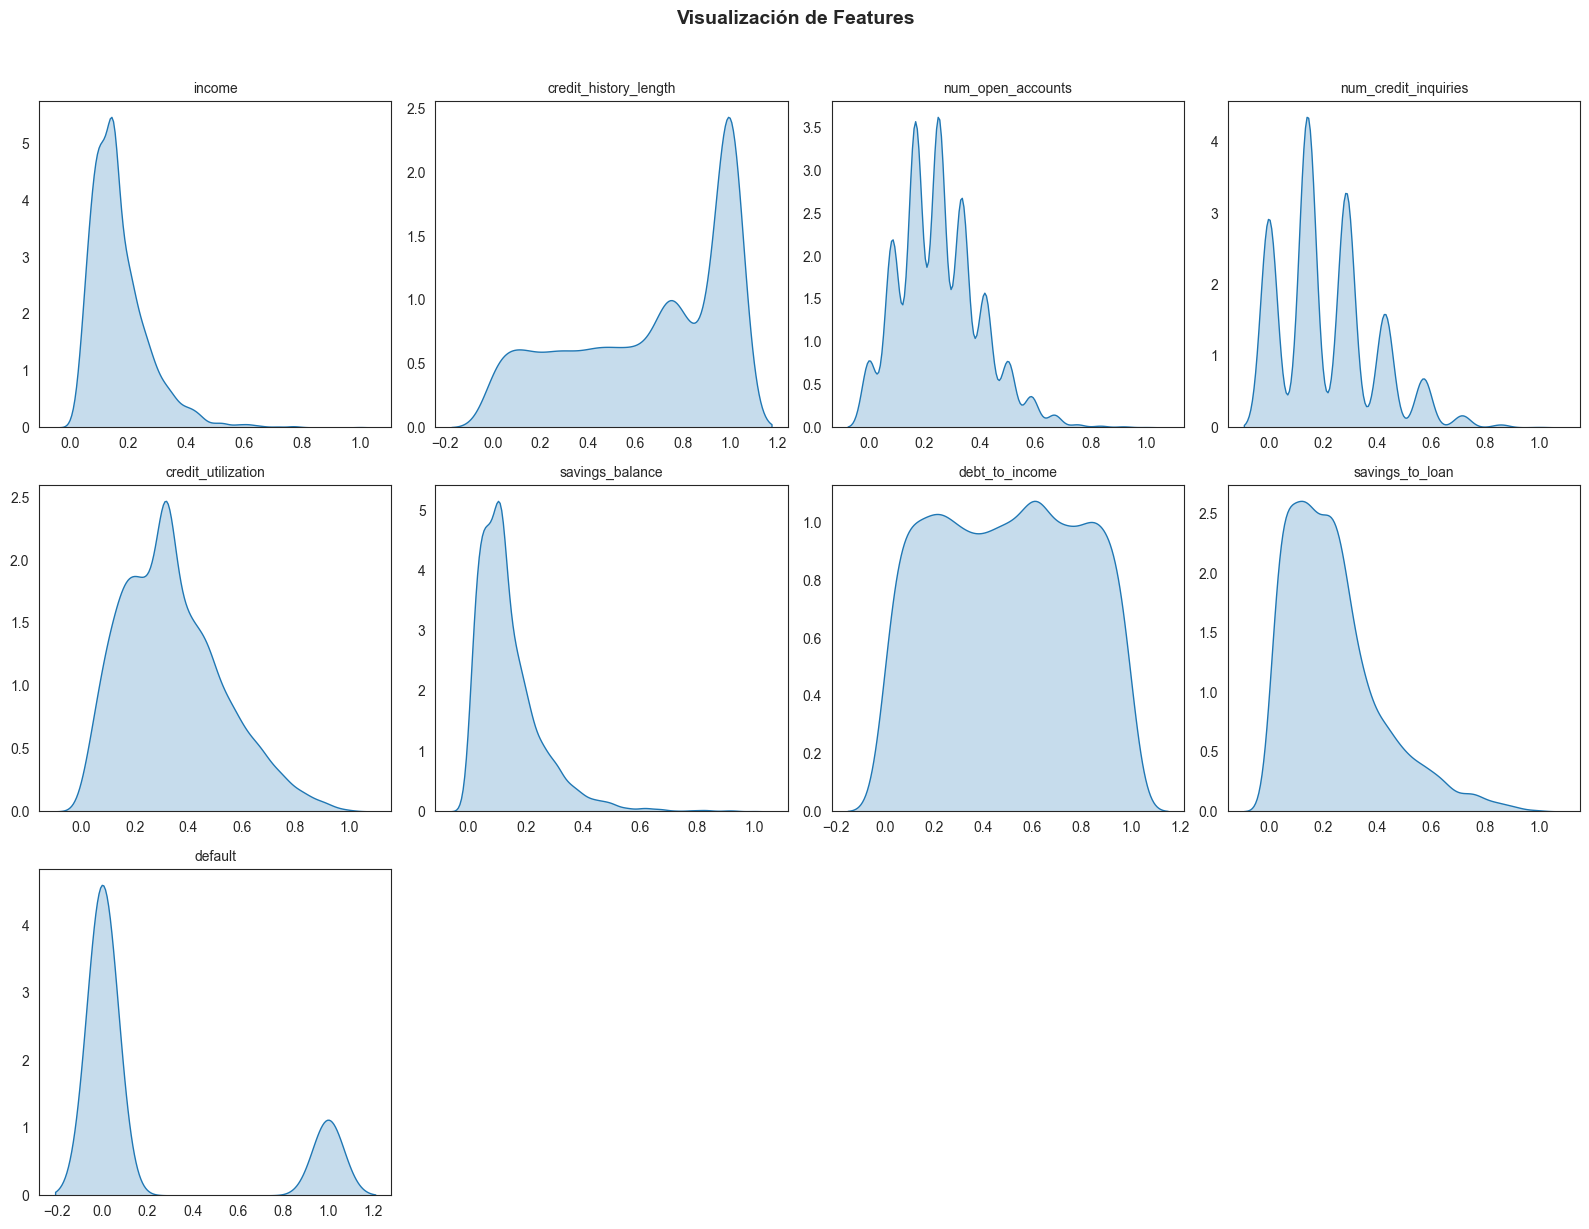

In [23]:
cols = list(df_clean.columns)

n = len(cols)
c = 4
r = math.ceil(n / c)

fig, axes = plt.subplots(r, c, figsize=(16, 4 * r)) 
axes = axes.flatten()

for ax, col in zip(axes, cols):
    if col in v_num:
        sns.kdeplot(df_clean[col].dropna(), ax=ax, fill=True)
    else:
        sns.countplot(data=df_clean, x=col, ax=ax, order=df_clean[col].value_counts().index)
        
        ax.tick_params(axis='x', rotation=45) 
    
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('') 
    ax.set_ylabel('')
    ax.grid(False)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Visualización de Features", y=1.02, fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [24]:
# calculamos el WOE para cada variable numérica con respecto a la variable target (default)



def calculate_woe(df_clean, feature, target, bins=5):
    df_temp = df_clean[[feature, target]].copy()
    
    if pd.api.types.is_numeric_dtype(df_temp[feature]):
        df_temp[feature] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    
    grouped = df_temp.groupby(feature)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    
    grouped['bad_dist'] = grouped['bad'] / grouped['bad'].sum()
    grouped['good_dist'] = grouped['good'] / grouped['good'].sum()
    
    grouped['WOE'] = np.log(grouped['good_dist'] / grouped['bad_dist'])
    
    return grouped[['total','good','bad','WOE']]

In [25]:
woe_default = calculate_woe(df_clean, "credit_history_length", "default")
print(woe_default)

                       total  good  bad       WOE
credit_history_length                            
(-0.001, 0.303]         1200   769  431 -0.833560
(0.303, 0.626]          1200   894  306 -0.340422
(0.626, 0.855]          1200   991  209  0.143838
(0.855, 1.0]            2400  2171  229  0.836679


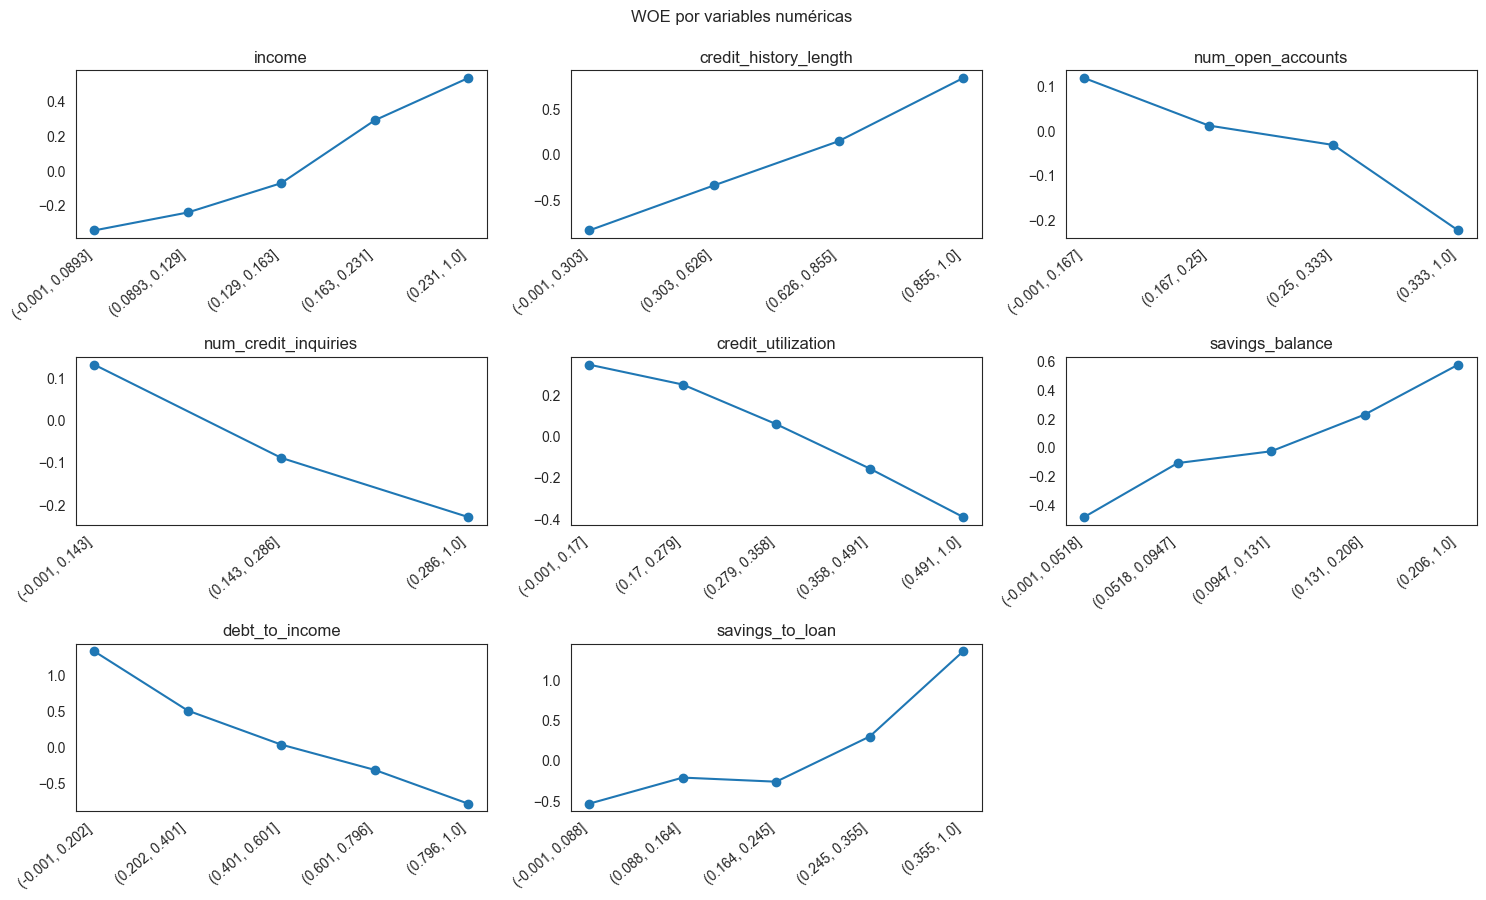

In [26]:
v_num_model = [col for col in v_num if col in df_clean.columns and col != "default"]

# 1. Calculamos el WOE 
woe_dict = {col: calculate_woe(df_clean, col, "default") for col in v_num_model}

n = len(woe_dict)
cols = 3                                
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3*rows))
axes = axes.flatten()

for ax, (col, woe_df) in zip(axes, woe_dict.items()):
    x_labels = woe_df.index.astype(str)
    
    ax.plot(x_labels, woe_df["WOE"], marker="o")
    ax.set_title(col)
    
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=40, ha='right')
    ax.grid(False)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("WOE por variables numéricas", y=0.995, fontsize=12)
fig.tight_layout()
plt.show()

In [27]:
def calculate_iv(df_clean, feature, target, bins=5):
    
    df_temp = df_clean[[feature, target]].copy()
    
    if pd.api.types.is_numeric_dtype(df_temp[feature]):
        df_temp[feature] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    
    grouped = df_temp.groupby(feature)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    
    grouped['bad_dist'] = grouped['bad'] / grouped['bad'].sum()
    grouped['good_dist'] = grouped['good'] / grouped['good'].sum()

    grouped['WOE'] = np.log(grouped['good_dist'] / grouped['bad_dist'])
    grouped['IV'] = (grouped['good_dist'] - grouped['bad_dist']) * grouped['WOE']
    
    iv_total = grouped['IV'].sum()
    
    return iv_total

In [28]:
print("income:", calculate_iv(df_clean, "income", "default"))

income: 0.10318348968112415


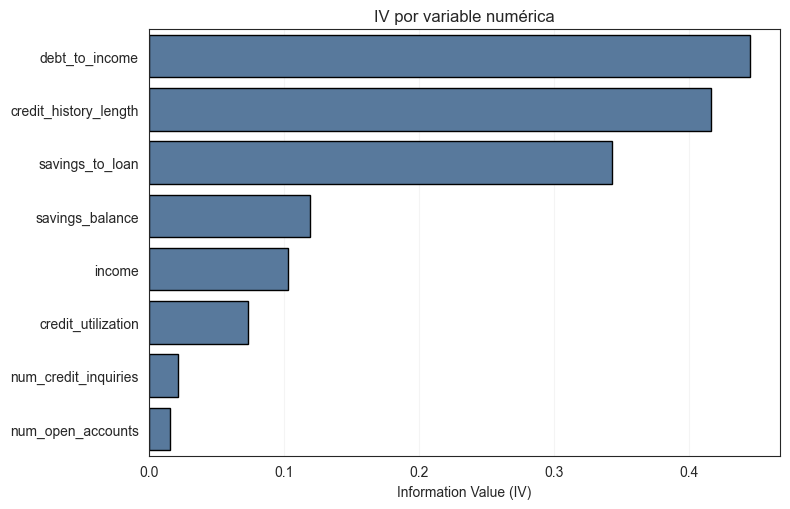

In [29]:
v_num_model = [col for col in v_num if col in df_clean.columns and col != "default"]


iv_list = []

for col in v_num_model:
    iv_val = calculate_iv(df_clean, col, "default", bins=5)
    iv_list.append({"variable": col, "IV": iv_val})

# Creamos el DataFrame y ordenamos de mayor a menor IV
iv_df = pd.DataFrame(iv_list).sort_values("IV", ascending=False).reset_index(drop=True)

# Generamos el gráfico
plt.figure(figsize=(8, 0.4*len(iv_df) + 2))
sns.barplot(data=iv_df, y="variable", x="IV", color="#4c78a8", edgecolor="black")
plt.title("IV por variable numérica")
plt.xlabel("Information Value (IV)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [30]:

    # WOE

# Creamos copias para no perder la data original
df_final = df_clean.copy()
dt_final = dt_clean.copy()

for col in v_num_model:
    # 1. Obtenemos los intervalos (bins) y sus valores WOE de tu diccionario
    woe_df = woe_dict[col]
    
    # Extraemos los intervalos del índice 
    bins_intervals = woe_df.index
    
    # Creamos un diccionario
    mapping = woe_df['WOE'].to_dict()
    
    # 2. Aplicamos a la base de entrenamiento
    df_final[f'{col}_woe'] = pd.cut(df_clean[col], bins=bins_intervals.categories, include_lowest=True)
    df_final[f'{col}_woe'] = df_final[f'{col}_woe'].map(mapping).astype(float)
    
    # 3. Aplicamos a la base de prueba
    dt_final[f'{col}_woe'] = pd.cut(dt_clean[col], bins=bins_intervals.categories, include_lowest=True)
    dt_final[f'{col}_woe'] = dt_final[f'{col}_woe'].map(mapping).astype(float)

print("¡Columnas _woe creadas con éxito!")


df_final.head()






¡Columnas _woe creadas con éxito!


,income,credit_history_length,num_open_accounts,num_credit_inquiries,credit_utilization,savings_balance,debt_to_income,savings_to_loan,default,income_woe,credit_history_length_woe,num_open_accounts_woe,num_credit_inquiries_woe,credit_utilization_woe,savings_balance_woe,debt_to_income_woe,savings_to_loan_woe
customer_id,,,,,,,,,,,,,,,,,
2215,0.127038,0.397183,0.333333,0.285714,0.479444,0.022183,0.110442,0.080626,0,-0.241500,-0.340422,-0.224134,-0.089530,-0.156562,-0.480448,1.324312,-0.537310
2582,0.284401,0.973486,0.333333,0.000000,0.274829,0.399982,0.882199,0.242853,0,0.533368,0.836679,-0.224134,0.130567,0.251899,0.572020,-0.786169,-0.264426
1662,0.164667,0.839814,0.250000,0.285714,0.446410,0.155670,0.118508,0.438551,0,0.289745,0.143838,0.011285,-0.089530,-0.156562,0.227201,1.324312,1.353865
3027,0.256261,0.599203,0.333333,0.428571,0.335067,0.165969,0.389475,0.185883,1,0.533368,-0.340422,-0.224134,-0.229306,0.059274,0.227201,0.503233,-0.264426
4343,0.091631,1.000000,0.416667,0.714286,0.080437,0.111813,0.607083,0.243918,0,-0.241500,0.836679,-0.224134,-0.229306,0.348445,-0.026248,-0.318370,-0.264426


In [31]:
# Sobreescribimos df_final para que solo tenga las columnas que terminan en _woe
df_final = df_final.filter(like='_woe')
dt_final = dt_final.filter(like='_woe')

# Mostramos las primeras filas para confirmar
df_final.head()

,income_woe,credit_history_length_woe,num_open_accounts_woe,num_credit_inquiries_woe,credit_utilization_woe,savings_balance_woe,debt_to_income_woe,savings_to_loan_woe
customer_id,,,,,,,,
2215,-0.241500,-0.340422,-0.224134,-0.089530,-0.156562,-0.480448,1.324312,-0.537310
2582,0.533368,0.836679,-0.224134,0.130567,0.251899,0.572020,-0.786169,-0.264426
1662,0.289745,0.143838,0.011285,-0.089530,-0.156562,0.227201,1.324312,1.353865
3027,0.533368,-0.340422,-0.224134,-0.229306,0.059274,0.227201,0.503233,-0.264426
4343,-0.241500,0.836679,-0.224134,-0.229306,0.348445,-0.026248,-0.318370,-0.264426


# modelamiento


In [32]:
# 1. Ver la lista completa y exacta de todas las columnas de df_final
print("Columnas actuales:")
print(df_final.columns.tolist())

# 2. Preguntarle directamente a Python si existe (te dirá True o False)
print("\n¿Existe la columna 'default'?:", 'default' in df_final.columns)

Columnas actuales:
['income_woe', 'credit_history_length_woe', 'num_open_accounts_woe', 'num_credit_inquiries_woe', 'credit_utilization_woe', 'savings_balance_woe', 'debt_to_income_woe', 'savings_to_loan_woe']

¿Existe la columna 'default'?: False


In [33]:
# Unimos df_final con la columna 'default' de df usando la llave 'customer_id'
df_final = pd.merge(df_final, df[['default']], on='customer_id', how='inner')


df_final.head()

,income_woe,credit_history_length_woe,num_open_accounts_woe,num_credit_inquiries_woe,credit_utilization_woe,savings_balance_woe,debt_to_income_woe,savings_to_loan_woe,default
customer_id,,,,,,,,,
2215,-0.241500,-0.340422,-0.224134,-0.089530,-0.156562,-0.480448,1.324312,-0.537310,0
2582,0.533368,0.836679,-0.224134,0.130567,0.251899,0.572020,-0.786169,-0.264426,0
1662,0.289745,0.143838,0.011285,-0.089530,-0.156562,0.227201,1.324312,1.353865,0
3027,0.533368,-0.340422,-0.224134,-0.229306,0.059274,0.227201,0.503233,-0.264426,1
4343,-0.241500,0.836679,-0.224134,-0.229306,0.348445,-0.026248,-0.318370,-0.264426,0


In [34]:
# El errors='ignore' evita que Python colapse si la columna ya no existe
df_final = df_final.drop(columns=['default_x', 'default_y'], errors='ignore')

# Veamos qué columnas sobrevivieron realmente en tu tabla
print("Estas son tus columnas oficiales y listas:")
print(df_final.columns.tolist())

Estas son tus columnas oficiales y listas:
['income_woe', 'credit_history_length_woe', 'num_open_accounts_woe', 'num_credit_inquiries_woe', 'credit_utilization_woe', 'savings_balance_woe', 'debt_to_income_woe', 'savings_to_loan_woe', 'default']


In [35]:
# nuevoooooooooooooooo MODELO ########################


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Usamos tu base original completa (df_final) que SÍ tiene el default
X_completo = df_final.drop(columns=['default'])
y_completo = df_final['default']

X_test_woe = dt_final.copy()

# 2. Partimos esta base en Train (70%) y un Test Interno (30%) para evaluarnos nosotros mismos
X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X_completo, y_completo, test_size=0.3, random_state=42, stratify=y_completo
)


# 4. Agregamos class_weight='balanced' para penalizar más los errores en los morosos
model = LogisticRegression(max_iter=1000, solver="lbfgs", class_weight='balanced')

# 5. Entrenamos el modelo con este nuevo balance
model.fit(X_train_int, y_train_int) # O X_train_woe / y_train_woe si estás usando la base original completa

# 6. generar las predicciones
y_test_pred_prob = model.predict_proba(X_test_int)[:, 1]
y_test_pred = model.predict(X_test_int)



In [36]:
# 7. Análisis de Coeficientes y Odds Ratio del Nuevo Modelo
coef_df = pd.DataFrame({
    "variable": X_train_int.columns,
    "coef": model.coef_[0],
    "abs_coef": np.abs(model.coef_[0]),
    "odds_ratio": np.exp(model.coef_[0])
}).sort_values("abs_coef", ascending=False)

# Mostramos los resultados con 4 decimales 
print("Interpretación de los Coeficientes del Modelo:")
coef_df.head(30).style.format({
    'coef': '{:.4f}',
    'abs_coef': '{:.4f}',
    'odds_ratio': '{:.4f}'
})

Interpretación de los Coeficientes del Modelo:


,variable,coef,abs_coef,odds_ratio
4,credit_utilization_woe,-1.4038,1.4038,0.2457
1,credit_history_length_woe,-1.1335,1.1335,0.3219
3,num_credit_inquiries_woe,-1.0672,1.0672,0.3440
0,income_woe,-0.9970,0.9970,0.3690
6,debt_to_income_woe,-0.9569,0.9569,0.3841
2,num_open_accounts_woe,-0.8241,0.8241,0.4386
7,savings_to_loan_woe,-0.5322,0.5322,0.5873
5,savings_balance_woe,-0.4045,0.4045,0.6673


# evalucion de desempeño

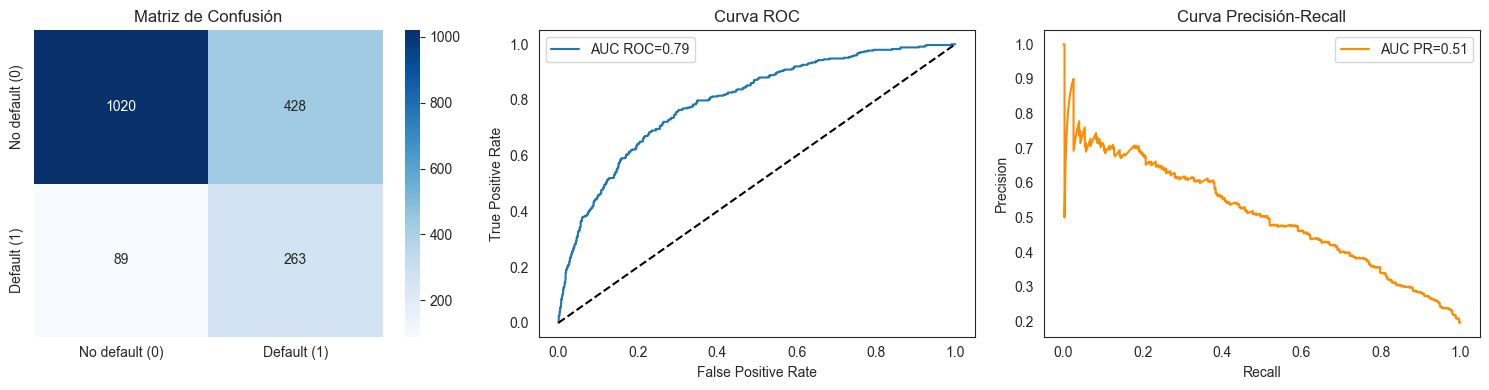

In [37]:

precisions, recalls, pr_thresholds = precision_recall_curve(y_test_int, y_test_pred_prob)
pr_auc = auc(recalls, precisions)
cm = confusion_matrix(y_test_int, y_test_pred)

plt.figure(figsize=(15, 4))

# 1. Matriz de Confusión
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No default (0)', 'Default (1)'],
            yticklabels=['No default (0)', 'Default (1)'])
plt.title('Matriz de Confusión')

# 2. Curva ROC
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test_int, y_test_pred_prob)
plt.plot(fpr, tpr, label=f'AUC ROC={auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# 3. Curva Precisión-Recall
plt.subplot(1, 3, 3)
plt.plot(recalls, precisions, label=f'AUC PR={pr_auc:.2f}', color='darkorange')
plt.title('Curva Precisión-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

plt.tight_layout()
plt.show()

In [38]:

fpr, tpr, thresholds = roc_curve(y_test_int, y_test_pred_prob)
youden_index = tpr - fpr

optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

print(f"🎯 El umbral óptimo matemático es: {optimal_threshold:.4f}")

🎯 El umbral óptimo matemático es: 0.4904


🔥 Búsqueda terminada. El mejor hiperparámetro 'C' encontrado es: 0.001


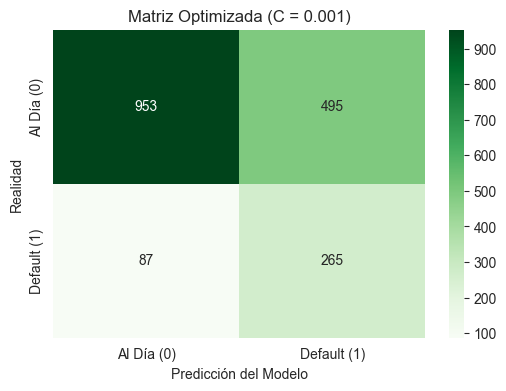

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# 1. Definimos las opciones que Python va a probar
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# 2. Configuramos balance
modelo_base = LogisticRegression(max_iter=1000, solver="lbfgs", class_weight='balanced')

# 3. Configuramos la Búsqueda 
grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    cv=5,               
    scoring='recall',   
    n_jobs=-1           
)

# 4. dentro del TEST INTERNO
grid_search.fit(X_train_int, y_train_int)

print(f"🔥 Búsqueda terminada. El mejor hiperparámetro 'C' encontrado es: {grid_search.best_params_['C']}")

# 5. Usamos el modelo ganador para predecir
mejor_modelo = grid_search.best_estimator_
y_test_pred_mejor = mejor_modelo.predict(X_test_int)

# 6. Dibujamos la Matriz de Confusión en verde
cm_mejorada = confusion_matrix(y_test_int, y_test_pred_mejor)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_mejorada, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Al Día (0)', 'Default (1)'],
            yticklabels=['Al Día (0)', 'Default (1)'])
plt.title(f"Matriz Optimizada (C = {grid_search.best_params_['C']})")
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()




# se han perdido muchos buenos clientes, solo por detectar a dos malos Pagadores, nos quedamos con el primer modelo.....

In [41]:
import pandas as pd

# 1. Usamos tu modelo original ('model') que mantiene tu AUC alto
probabilidades = model.predict_proba(X_test_woe)[:, 1]

# 2. Armamos la tabla con los nombres EXACTOS de la foto
submission = pd.DataFrame({
    'customer_id': X_test_woe.index, 
    'default_probability': probabilidades
})

# 3. Guardamos el CSV (Mantenemos todos los decimales para proteger tu puntaje AUC)
submission.to_csv('submission_competencia.csv', index=False)

print(submission.head())

   customer_id  default_probability
0            2             0.192788
1            3             0.224314
2            4             0.910948
3            5             0.195010
4            9             0.766982
